In [124]:
!pip install tensorflow opencv-python matplotlib numpy

In [125]:
!pip list

Package                 Version
----------------------- -----------
absl-py                 2.3.1
asttokens               3.0.0
astunparse              1.6.3
certifi                 2025.8.3
charset-normalizer      3.4.3
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.17
decorator               5.2.1
executing               2.2.1
flatbuffers             25.9.23
fonttools               4.60.0
gast                    0.6.0
google-pasta            0.2.0
grpcio                  1.75.0
h5py                    3.14.0
idna                    3.10
ipykernel               6.30.1
ipython                 9.5.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
jupyter_client          8.6.3
jupyter_core            5.8.1
keras                   3.11.3
kiwisolver              1.4.9
libclang                18.1.1
Markdown                3.9
markdown-it-py          4.0.0
MarkupSafe           

In [126]:
import tensorflow as tf
import os

In [127]:
os.path.join('data','happy')
#creates files data and happy . listdir brings all the contents in the file

'data\\happy'

In [128]:
gpus = tf.config.experimental.list_physical_devices('GPU')

In [129]:
len(gpus)

0

In [130]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
    #limits the memory growth by using the min number of required gpus

Remove dodgy images 


In [131]:
import cv2
import imghdr
from matplotlib import pyplot as plt

In [132]:
data_dir = 'data'
#pointer for controlling data folder

In [133]:
os.listdir(data_dir)


['happy', 'sad']

In [134]:
image_exts = ['jpeg', 'jpg' , 'bmp', 'png']

In [135]:
img = cv2.imread(os.path.join('data','happy','4-things-happy-people-dont-do-cover.png'))

In [136]:
img.shape

(933, 1400, 3)

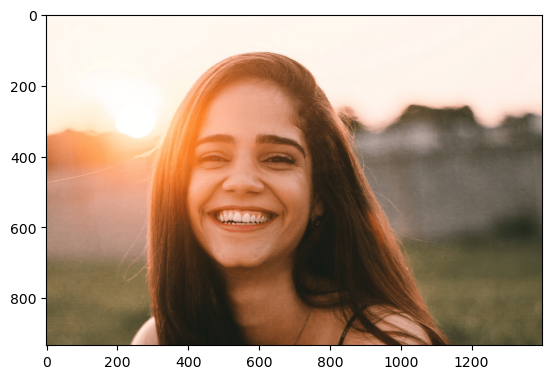

In [137]:
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

In [138]:
for image_class in os.listdir(data_dir):  #looping through every folder
    for image in os.listdir(os.path.join(data_dir,image_class)): #looping through every image in that folder
        image_path = os.path.join(data_dir, image_class,image) 
        try:
            img = cv2.imread(image_path) #loading images to opencv
            tip = imghdr.what(image_path) #check the image extension
            if tip not in image_exts: #if image extension != image_exts[] remove them/ dont select them
                print('Image not matching ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))



LOAD DATA


In [139]:
import numpy as np
from matplotlib import pyplot as plt

In [140]:
data = tf.keras.utils.image_dataset_from_directory('data')
# helper which takes the data from directory resizes them and preprocess them so that it can be fed to models appropriately and efficiently in batches

Found 162 files belonging to 2 classes.


In [141]:
data_iterator = data.as_numpy_iterator()

In [142]:
batch = data_iterator.next()
#get next batch from the iterator

In [143]:
batch[0].shape
#images represented as numpy arrays
# batch_size, image_size,image_size, RGB 

(32, 256, 256, 3)

In [144]:
batch[0] 
# returns images from the batch

array([[[[153.       , 186.       , 205.       ],
         [152.       , 185.       , 204.       ],
         [152.       , 185.       , 204.       ],
         ...,
         [203.51953  , 206.7461   , 205.7461   ],
         [119.74219  , 120.91016  , 115.078125 ],
         [ 78.44531  ,  79.44531  ,  73.44531  ]],

        [[153.       , 186.       , 205.       ],
         [152.       , 185.       , 204.       ],
         [152.       , 185.       , 204.       ],
         ...,
         [203.51953  , 206.7461   , 205.7461   ],
         [119.74219  , 120.91016  , 115.078125 ],
         [ 78.44531  ,  79.44531  ,  73.44531  ]],

        [[153.       , 186.       , 203.85547  ],
         [152.       , 185.       , 202.85547  ],
         [152.       , 185.       , 202.85547  ],
         ...,
         [203.51953  , 206.7461   , 205.7461   ],
         [119.74219  , 120.91016  , 115.078125 ],
         [ 78.44531  ,  79.44531  ,  72.30078  ]],

        ...,

        [[158.       , 149.       , 14

In [145]:
batch[1]
#returns labels for each image where 0 is happy and 1 is for sad

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 0, 1, 1])

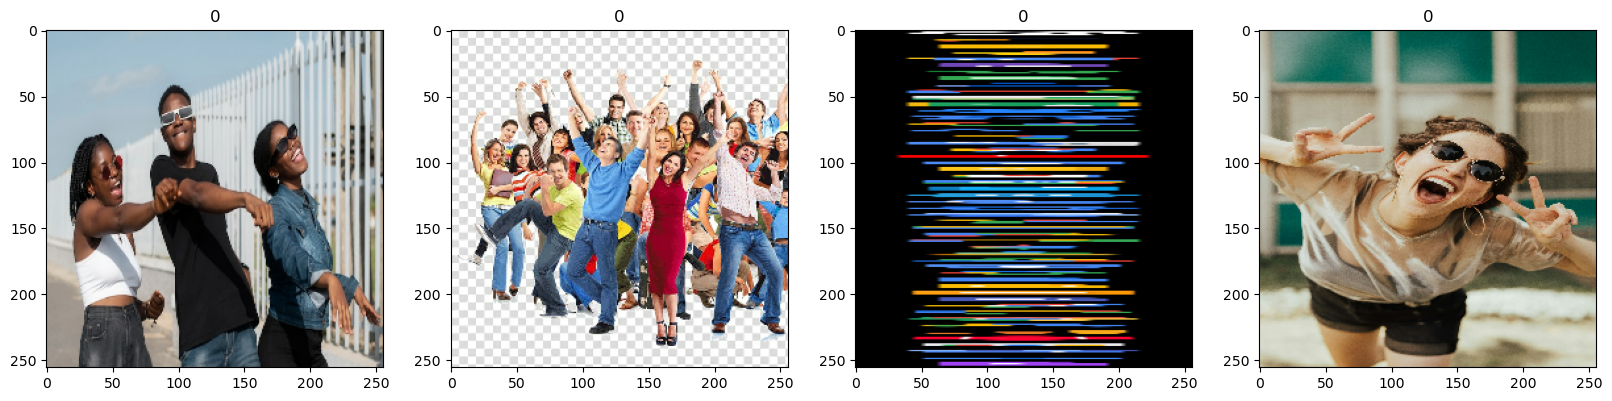

In [146]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20)) #creates a figure and array ax ncols = 4 means 4 images in 1 row and fig size is 20,20
for idx, img in enumerate(batch[0][:4]): # returns index and takes 4 images from batch
    ax[idx].imshow(img.astype(int))      #displays the image,  img.astype(int) -> coverts pixel values into integers 
    ax[idx].title.set_text(batch[1][idx]) # sets the label as the title of the image

PREPROCESS DATA -> SCALING IMAGES VALUES TO 0-1 INSTEAD OF 0-255. DL models reqiuire valus as low as possible for optimal results so divide generally by max value ie 255

In [147]:
data = data.map(lambda x,y: (x/255, y))
#map -> transforms data when just before it is being fetched for the batch through the pipeline. 
# x is images , y is target variable 

In [148]:
 scaled_iterator = data.as_numpy_iterator()

In [149]:
batch = scaled_iterator.next()

In [150]:
batch[0].max()

1.0

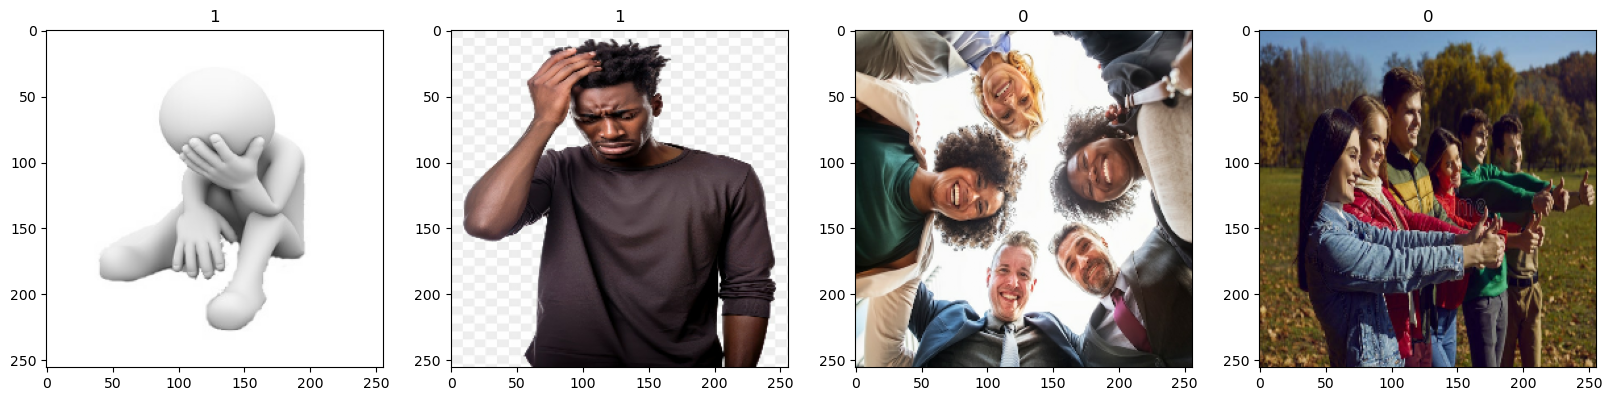

In [151]:
fig, ax = plt.subplots(ncols=4, figsize=(20,20)) #creates a figure and array ax ncols = 4 means 4 images in 1 row and fig size is 20,20
for idx, img in enumerate(batch[0][:4]): # returns index and takes 4 images from batch
    ax[idx].imshow(img)      #displays the image, 
    ax[idx].title.set_text(batch[1][idx]) # sets the label as the title of the image

Split data so it doesnot over fit


In [152]:
len(data)
#total number of batches

6

In [153]:
train_size = int(len(data)*.7)
val_size = int(len(data)*.2)
test_size = int(len(data)*.1)+1

In [154]:
train_size+val_size+test_size # must be equal to number of batches

6

In [155]:
#take defines how much data is taken in testing
#skip the batches already taken

train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

DEEP MODEL

In [156]:

# Sequential -> one data i/p and one o/p 
# Functional -> multiple i/p and multiple o/p
#conv2D -> 2d cnn for images , maxpooling condenses the images 

from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Input(shape=(256,256,3)),   # ✅ input defined here
    Conv2D(16, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    Flatten(),
    
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])



In [157]:
model.compile('adam', loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])
#adam is a optimiser loss is specified for binary classification

In [158]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)                   │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 60, 60, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_14 (MaxPooling2D)      │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,396,641 (28.22 MB)

 Trainable params: 7,396,641 (28.22 MB)

 Non-trainable params: 0 (0.00 B)

TRAIN

In [159]:
early_stopping = EarlyStopping(
    monitor='val_loss',      # Monitor the validation loss
    patience=5,              # Stop if it doesn't improve for 5 consecutive epochs
    restore_best_weights=True # Restore the weights from the best epoch
)

In [160]:
logdir = 'logs'

In [161]:
from tensorflow.keras.callbacks import EarlyStopping,TensorBoard

In [162]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)
#used to save a checkpoint and save a log it logdir

In [163]:
#early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
# patienece is the no. of epochs to wait b4 rollback, roll back to best epoch

In [184]:
#Train for more epochs, but EarlyStopping will find the best stopping point
hist = model.fit(
    train, 
    epochs=40, # Increased max epochs
    validation_data=val, 
    callbacks=[tensorboard_callback, early_stopping] # Add the new callback
)
#epochs is running time , train gives model o/ps and validates using validation data

Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9922 - loss: 0.0324 - val_accuracy: 1.0000 - val_loss: 0.0361
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9844 - loss: 0.0415 - val_accuracy: 0.9688 - val_loss: 0.0928
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9844 - loss: 0.0639 - val_accuracy: 0.9688 - val_loss: 0.0478
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9844 - loss: 0.0365 - val_accuracy: 1.0000 - val_loss: 0.0083
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9766 - loss: 0.0634 - val_accuracy: 0.9688 - val_loss: 0.0591
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9844 - loss: 0.0396 - val_accuracy: 1.0000 - val_loss: 0.0186
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.9844 - loss: 0.0660 - val_accuracy: 1.0000 - val_loss: 0.0273
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.9844 - loss: 0.0318 - val_accuracy: 1.0000 - val_loss: 0.0216
Epoch 9/40
4/4 ━

PLOT PERFORMANCE

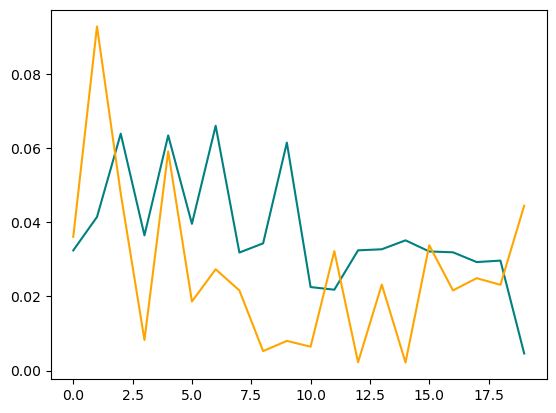

In [185]:
fig = plt.figure()
plt.plot(hist.history['loss'], color = 'teal', label = 'loss')
plt.plot(hist.history['val_loss'], color = 'orange', label = 'val_loss')

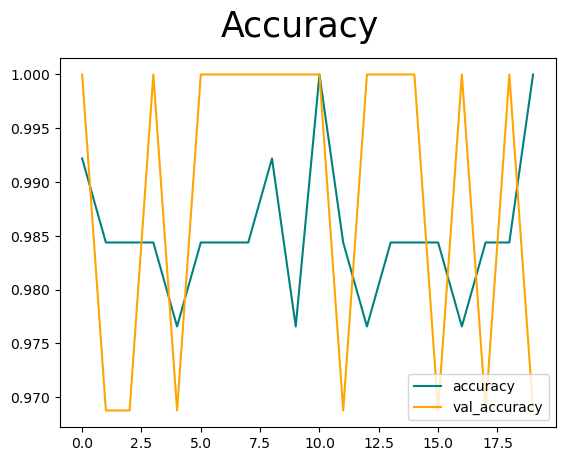

In [186]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color = 'teal', label = 'accuracy')
plt.plot(hist.history['val_accuracy'], color = 'orange', label = 'val_accuracy')
fig.suptitle('Accuracy', fontsize = 25)
plt.legend(loc = "lower right")
plt.show()
#

VALIDATION

In [187]:
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy


In [188]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [189]:
for batch in test.as_numpy_iterator():
    X, y = batch #x = image, y is the true value
    yhat = model.predict(X) #returns a value of 0 or 1(predicted value according to the model based on training) . predict is used for validation , model.fit is used for training
    pre.update_state(y, yhat) # checks precission b/w true value and predicted value
    re.update_state(y, yhat)
    acc.update_state(y, yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


In [190]:
print(f'Precision:{pre.result().numpy()},Recall:{re.result().numpy()}, Accuracy:{acc.result().numpy()}')

Precision:1.0,Recall:1.0, Accuracy:1.0


TESTING

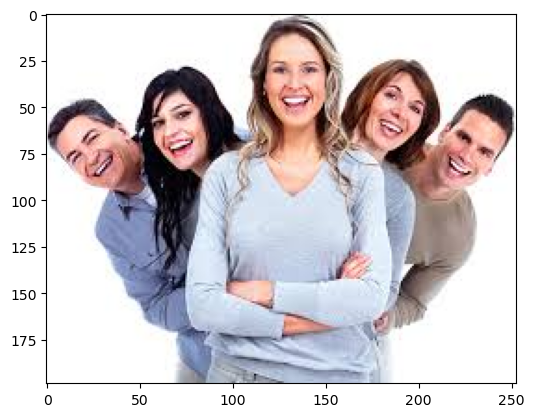

In [217]:
img = cv2.imread('happy1.jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

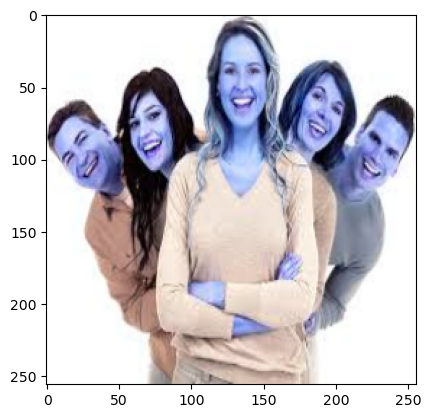

In [218]:
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [219]:
resize.shape

TensorShape([256, 256, 3])

In [220]:
np.expand_dims(resize,0).shape

(1, 256, 256, 3)

In [221]:
yhat = model.predict(np.expand_dims(resize/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


In [222]:
yhat

array([[0.02688495]], dtype=float32)

In [223]:
if yhat > 0.5:
    print(f'The class is predicted to be SAD')
else:
    print(f'The class is predicted to be HAPPY')

The class is predicted to be HAPPY


SAVE THE MODEL

In [224]:
from tensorflow.keras.models import load_model

In [225]:
model.save(os.path.join('models','happysadmodel.h5'))
#saves the model in the models folder so that it can be used again by recalling

In [226]:
os.path.join('models','happysadmodel.h5')

'models\\happysadmodel.h5'

In [227]:
new_model = load_model(os.path.join('models','happysadmodel.h5'))

In [228]:
yhatnew = new_model.predict(np.expand_dims(resize/255,0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


In [229]:
if yhat > 0.5:
    print(f'The class is predicted to be SAD')
else:
    print(f'The class is predicted to be HAPPY')

The class is predicted to be HAPPY
